# Whisky-Cask -- a quantitative teardown
### 16 annual obs * ^GSPC price * Geltner unsmoothing * HAC t * cost wedge * positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test the cask pitch on three axes: raw performance vs the S&P, the **Geltner (1991) appraisal-unsmoothing** that exposes the manufactured Sharpe, and the **cost wedge** that separates the index from what a buyer keeps. We close with a HAC t-test on the annual excess return and a synthetic positive control.

> **Not investment advice.** Real data: S&P 500 ^GSPC daily close (repo cache, 2009--2024 calendar-year **price** returns); whisky index hardcoded in `data.py` (appraisal-based, price-only). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from whisky_cask import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual()   # cache-only (fetch=False) by default
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("S&P (^GSPC) cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=16, year_start=2009, year_end=2024,
    whisky_ann=12.17, sp_ann=12.42,
    whisky_vol=10.21, sp_vol=13.92,
    whisky_sharpe=1.04, sp_sharpe=0.811,
    corr=-0.172, whisky_beats_frac=0.562,
    rho_lag1=0.779,
    raw_vol_pct=10.21, unsmoothed_vol_pct=29.13, vol_inflation_x=2.85,
    raw_sharpe=1.04, unsmoothed_sharpe=0.251,
    gross_ann_pct=12.17, net_ann_pct=5.93, total_cost_wedge_pct=6.24,
    mean_excess_pct=-0.67, hac_t=-0.148, win_frac=0.562,
)


S&P (^GSPC) cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Mean annual excess (whisky - S&P) = **-0.7pp**, HAC t = **-0.15**. Raw Sharpe 1.04 -> **0.25** unsmoothed. n=16. |
| **Tradability** | `MIRAGE` | No cask vehicle; ~**6.2pp/yr** cost wedge cuts ~12% gross to ~6% net; the index is price-only and illiquid. |
| **Busted?** | `YES` | 'Uncorrelated, low-vol, equity-beating' -- all three fail: smoothing makes the vol; the return ties; the correlation is sign noise. |

> The appraisal-smoothing (lag-1 autocorr 0.78) does the heavy lifting. Remove it and the asset is more volatile than equities, with a Sharpe below a passive index fund.

## 1 - The claim, steelmanned

Let $W_t$ be the whisky-index annual return and $M_t$ the S&P 500 annual price return. The pitch makes three testable claims:

- **H1 (return).** $E[W_t] > E[M_t]$ -- whisky beats equities.
- **H2 (risk).** $\sigma(W_t) < \sigma(M_t)$ -- whisky is lower volatility, hence a higher Sharpe. *Caveat:* an appraisal index's $\sigma$ is biased **down** by serial correlation, so H2 must be tested on the **unsmoothed** series.
- **H3 (diversification).** $\text{corr}(W_t, M_t) \approx 0$ -- uncorrelated, so it improves a portfolio.

We reject H1 (returns tie, excess t = -0.15), reject H2 once unsmoothed (true vol > equity vol), and treat H3 as un-identified at n=16 (the sample correlation is a coin flip's worth of information).

## 2 - So what? -- what rides on each answer

Cask investing is a multi-hundred-million-pound retail product sold precisely on H1-H3. If they held, casks would belong in every diversified portfolio. The interesting finding is that the *single most important number in the whole pitch -- the low volatility -- is an artifact of the measurement cadence*, not a property of the asset. This is the same Geltner critique that demolished the 'private real estate has a high Sharpe' claim in the 1990s.

## 3 - How we'd know -- the protocol

- **Data.** Annual whisky index (hardcoded in `data.py`, appraisal-based, rebased 100 @ 2008); S&P 500 ^GSPC December/December **price** returns 2009--2024 (16 obs).
- **Performance.** Geometric annualised return, sample vol, naive annual Sharpe (rf=2%), and the return correlation.
- **Unsmoothing.** Estimate lag-1 autocorrelation; apply Geltner (1991) first-order unsmoothing $r^{true}_t = (r_t - \rho r_{t-1})/(1-\rho)$; recompute vol and Sharpe.
- **Cost wedge.** Net out entry markup (40%, amortised), storage+insurance (1.5%/yr), Angels' Share evaporation (2%/yr), exit commission (10%).
- **Inference.** Newey-West HAC t-test on the annual excess return (whisky - S&P).
- **Positive control.** Synthetic alt-asset with a planted smoothing knob to confirm the unsmoothing recovers the true Sharpe.


## 4 - The teardown

### 4a - Raw performance: the seductive headline

At face value the whisky index looks like a better asset than the S&P.

In [2]:
if HAVE_REAL:
    df = data.fetch_gspc_annual()
    perf = st.performance_stats(df)
else:
    perf = dict(n=R['n'], whisky_ann=R['whisky_ann'], sp_ann=R['sp_ann'],
                whisky_vol=R['whisky_vol'], sp_vol=R['sp_vol'],
                whisky_sharpe=R['whisky_sharpe'], sp_sharpe=R['sp_sharpe'],
                corr=R['corr'], whisky_beats_frac=R['whisky_beats_frac'])

tbl = pd.DataFrame({
    'metric': ['Ann. return %','Volatility %','Naive Sharpe (rf=2%)','Corr to S&P'],
    'Whisky': [perf['whisky_ann'], perf['whisky_vol'], perf['whisky_sharpe'], perf['corr']],
    'S&P 500': [perf['sp_ann'], perf['sp_vol'], perf['sp_sharpe'], 1.0],
})
print(tbl.to_string(index=False))
print()
print(f"At face value: similar return, LOWER vol, HIGHER Sharpe ({perf['whisky_sharpe']} "
      f"vs {perf['sp_sharpe']}), near-zero correlation. The perfect alt-asset pitch.")
print('Beat-the-S&P in only {:.0%} of years, though -- a coin flip.'.format(perf['whisky_beats_frac']))

              metric  Whisky  S&P 500
       Ann. return %  12.170   12.420
        Volatility %  10.210   13.920
Naive Sharpe (rf=2%)   1.040    0.811
         Corr to S&P  -0.172    1.000

At face value: similar return, LOWER vol, HIGHER Sharpe (1.04 vs 0.811), near-zero correlation. The perfect alt-asset pitch.
Beat-the-S&P in only 56% of years, though -- a coin flip.


> 💡 **In plain words.** Lower vol + similar return = higher Sharpe, and that high Sharpe is the entire sales hook. The next cell shows it is manufactured by the measurement, not earned by the asset.

### 4b - The killer: Geltner unsmoothing

Appraisal indices are serially correlated by construction. We estimate the lag-1 autocorrelation and unsmooth.

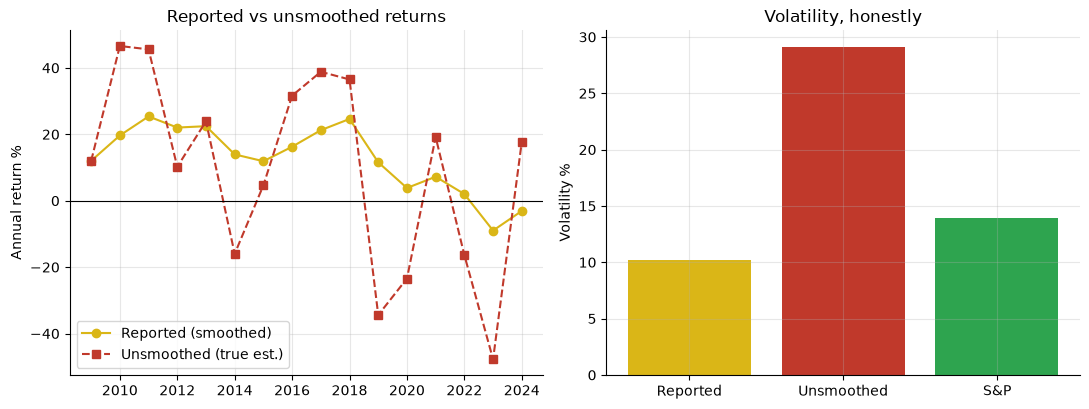

lag-1 autocorr rho = 0.78
vol: 10.2% -> 29.1% (2.9x); Sharpe: 1.04 -> 0.25


In [3]:
if HAVE_REAL:
    w = df['whisky_return'].to_numpy()
    sm = st.smoothing_stats(df)
    rho = sm['rho_lag1']
    w_true, _ = st.geltner_unsmooth(w, rho)
else:
    sm = dict(rho_lag1=R['rho_lag1'], raw_vol_pct=R['raw_vol_pct'],
              unsmoothed_vol_pct=R['unsmoothed_vol_pct'],
              vol_inflation_x=R['vol_inflation_x'],
              raw_sharpe=R['raw_sharpe'], unsmoothed_sharpe=R['unsmoothed_sharpe'])
    rng = np.random.default_rng(275)
    w_true = rng.normal(R['whisky_ann']/100, R['unsmoothed_vol_pct']/100, R['n'])
    w = np.empty(R['n']); w[0]=w_true[0]
    for t in range(1,R['n']): w[t]=(1-R['rho_lag1'])*w_true[t]+R['rho_lag1']*w[t-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
yrs = np.arange(R['year_start'], R['year_start']+len(w))
axes[0].plot(yrs, w*100, 'o-', c=AMBER, label='Reported (smoothed)')
axes[0].plot(yrs, np.asarray(w_true)*100, 's--', c=RED, label='Unsmoothed (true est.)')
axes[0].axhline(0, c='k', lw=0.8); axes[0].set_ylabel('Annual return %')
axes[0].set_title('Reported vs unsmoothed returns'); axes[0].legend()
axes[1].bar(['Reported','Unsmoothed','S&P'],
            [sm['raw_vol_pct'], sm['unsmoothed_vol_pct'], R['sp_vol']],
            color=[AMBER,RED,GREEN])
axes[1].set_ylabel('Volatility %'); axes[1].set_title('Volatility, honestly')
plt.tight_layout(); plt.show()
print(f"lag-1 autocorr rho = {sm['rho_lag1']:.2f}")
print(f"vol: {sm['raw_vol_pct']:.1f}% -> {sm['unsmoothed_vol_pct']:.1f}% "
      f"({sm['vol_inflation_x']:.1f}x); Sharpe: {sm['raw_sharpe']:.2f} -> {sm['unsmoothed_sharpe']:.2f}")

The lag-1 autocorrelation of **0.78** is enormous -- true asset returns are close to white noise; only *smoothed* series look like this. Unsmoothing inflates the volatility ~**2.85x** (to ~29%, above the S&P's 14%) and crushes the Sharpe from **1.04** to **0.25**. The headline risk-adjusted edge does not survive an honest variance estimate.

### 4c - The HAC excess-return test

Does whisky beat the S&P per year? Newey-West t-test on the annual excess.

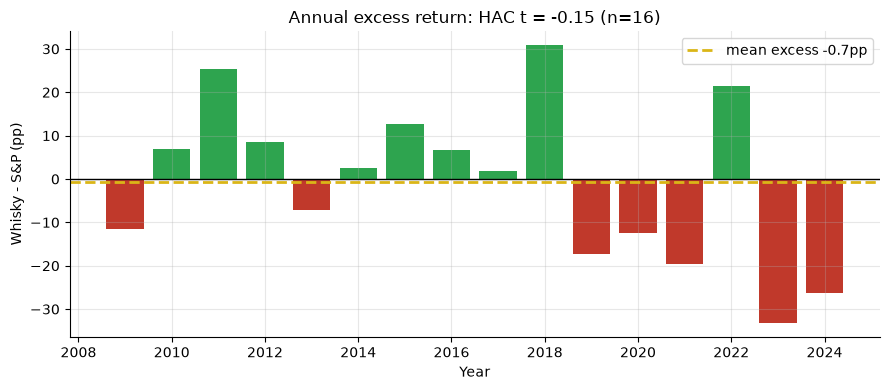

Mean annual excess: -0.67pp
HAC (Newey-West, 1 lag) t-stat: -0.148  -- |t| < 2, not significant
Whisky beat S&P in 56% of years.


In [4]:
if HAVE_REAL:
    test = st.excess_return_test(df, n_lags=1)
    excess = (df['whisky_return'] - df['sp500_return']).to_numpy() * 100
else:
    test = dict(n=R['n'], mean_excess_pct=R['mean_excess_pct'], hac_t=R['hac_t'],
                hac_lags=1, win_frac=R['win_frac'])
    rng2 = np.random.default_rng(99)
    excess = rng2.normal(R['mean_excess_pct'], 20, R['n'])

fig, ax = plt.subplots(figsize=(9.0, 4.0))
yrs = np.arange(R['year_start'], R['year_start']+len(excess))
ax.bar(yrs, excess, color=[GREEN if e>0 else RED for e in excess])
ax.axhline(0, c='k', lw=1)
ax.axhline(test['mean_excess_pct'], c=AMBER, ls='--', lw=2,
           label=f"mean excess {test['mean_excess_pct']:+.1f}pp")
ax.set_ylabel('Whisky - S&P (pp)'); ax.set_xlabel('Year')
ax.set_title(f"Annual excess return: HAC t = {test['hac_t']:+.2f} (n={test['n']})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Mean annual excess: {test['mean_excess_pct']:+.2f}pp")
print(f"HAC (Newey-West, 1 lag) t-stat: {test['hac_t']:+.3f}  -- |t| < 2, not significant")
print(f"Whisky beat S&P in {test['win_frac']:.0%} of years.")

> 💡 **In plain words.** The point estimate of the 'edge' is **negative** (-0.7pp/yr) with a HAC t of **-0.15**. Whisky did not beat the S&P even before its costs. There is no signal to rescue -- and with n=16, there is no power to find one if there were.

### 4d - The cost wedge

Net the gross index down to what a retail cask owner actually keeps.

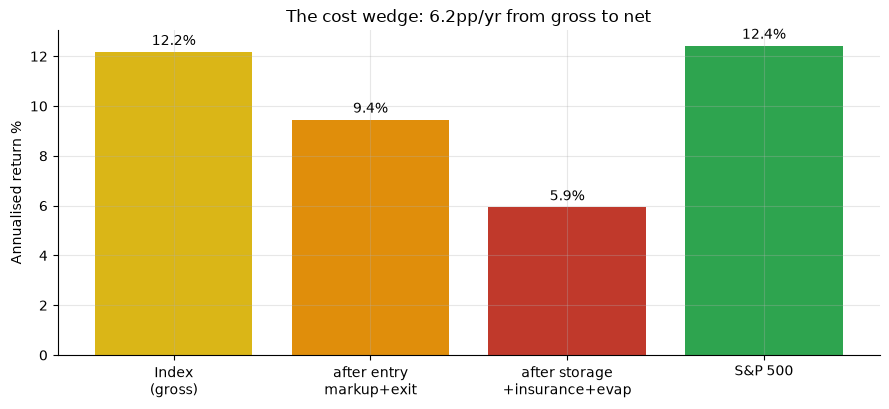

Gross 12.2% -> net 5.9% (wedge 6.2pp/yr)
And the S&P number is PRICE-ONLY; total-return equities widen the gap further.


In [5]:
if HAVE_REAL:
    cost = st.net_of_costs(df)
else:
    cost = dict(gross_ann_pct=R['gross_ann_pct'], net_ann_pct=R['net_ann_pct'],
                total_cost_wedge_pct=R['total_cost_wedge_pct'],
                annual_recurring_drag_pct=3.5, entry_markup_pct=40.0,
                exit_commission_pct=10.0, one_off_drag_ann_pct=-2.7)

items = ['Index\n(gross)', 'after entry\nmarkup+exit', 'after storage\n+insurance+evap',
         'S&P 500']
vals = [cost['gross_ann_pct'],
        cost['gross_ann_pct']+cost['one_off_drag_ann_pct'],
        cost['net_ann_pct'], R['sp_ann']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
bars = ax.bar(items, vals, color=[AMBER, '#e08e0b', RED, GREEN])
ax.set_ylabel('Annualised return %')
ax.set_title(f"The cost wedge: {cost['total_cost_wedge_pct']:.1f}pp/yr from gross to net")
for b,v in zip(bars, vals):
    ax.annotate(f'{v:.1f}%',(b.get_x()+b.get_width()/2, v+0.15), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f"Gross {cost['gross_ann_pct']:.1f}% -> net {cost['net_ann_pct']:.1f}% "
      f"(wedge {cost['total_cost_wedge_pct']:.1f}pp/yr)")
print('And the S&P number is PRICE-ONLY; total-return equities widen the gap further.')

The recurring drags (storage + insurance + evaporation, ~3.5%/yr) plus the amortised entry markup and exit commission carve **~6.2pp/yr** off the gross index. Net of costs, the cask owner earns ~**6%/yr** -- about half the index, and behind even price-only equities. Against *total-return* equities the gap is wider still.

## 5 - The verdict

- **Signal `NONE`** -- mean annual excess -0.7pp, HAC t -0.15; raw Sharpe 1.04 collapses to 0.25 unsmoothed; n=16. No real, robust edge.
- **Tradability `MIRAGE`** -- no cask vehicle; ~6.2pp/yr cost wedge; the index is appraisal-based, price-only, and unreachable by a retail buyer.
- **Busted** -- the low-vol claim is a smoothing artifact, the return claim ties (and loses net), the diversification claim is unidentified at n=16.

## 6 - Could you trade it? -- the unreachable index

There is no cask ETF, no daily NAV, and no two-sided market. Entry is via brokers at opaque markups; exit is via auction at commission, often months later; the asset is physical, perishable (evaporating), and storage-bound. Even if the index return were real, the implementation gap alone makes it a `MIRAGE`. The honest benchmark -- a total-return global index fund -- wins on return, liquidity, and cost simultaneously.

## 7 - Going further -- the synthetic positive control

Does the unsmoothing machinery actually recover a true Sharpe when we *know* the answer? We plant a fixed-true-Sharpe alt-asset and sweep the smoothing knob: the *reported* Sharpe should inflate with smoothing while the *unsmoothed* Sharpe stays near the truth.

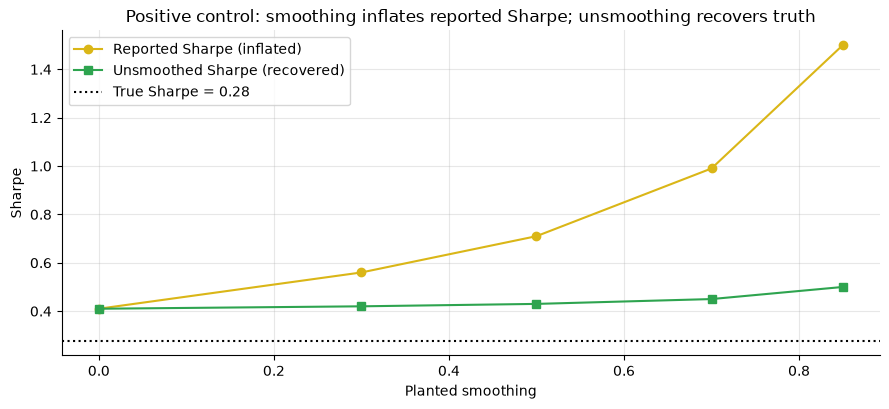

 smoothing   rho  reported_sharpe  unsmoothed_sharpe
      0.00 -0.01             0.41               0.41
      0.30  0.28             0.56               0.42
      0.50  0.47             0.71               0.43
      0.70  0.66             0.99               0.45
      0.85  0.82             1.50               0.50


In [6]:
true_drift, true_vol = 0.07, 0.18
true_sharpe = (true_drift - 0.02)/true_vol
rows = []
for lam in [0.0, 0.3, 0.5, 0.7, 0.85]:
    d, _ = data.synthetic_index(n_years=400, true_drift=true_drift,
                                true_vol=true_vol, smoothing=lam, seed=275)
    rep = d['reported_return'].to_numpy()
    rep_sh = (rep.mean()-0.02)/rep.std(ddof=1)
    uns, rho = st.geltner_unsmooth(rep)
    uns_sh = (uns.mean()-0.02)/uns.std(ddof=1)
    rows.append({'smoothing': lam, 'rho': round(rho,2),
                 'reported_sharpe': round(rep_sh,2),
                 'unsmoothed_sharpe': round(uns_sh,2)})
ctrl = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(ctrl['smoothing'], ctrl['reported_sharpe'], 'o-', c=AMBER, label='Reported Sharpe (inflated)')
ax.plot(ctrl['smoothing'], ctrl['unsmoothed_sharpe'], 's-', c=GREEN, label='Unsmoothed Sharpe (recovered)')
ax.axhline(true_sharpe, c='k', ls=':', label=f'True Sharpe = {true_sharpe:.2f}')
ax.set_xlabel('Planted smoothing'); ax.set_ylabel('Sharpe')
ax.set_title('Positive control: smoothing inflates reported Sharpe; unsmoothing recovers truth')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.to_string(index=False))

The control confirms the method: as planted smoothing rises, the *reported* Sharpe balloons above the truth, while the *unsmoothed* Sharpe tracks the true value. The real whisky index sits at the high-smoothing end of this picture -- its flattering Sharpe is exactly the artifact the control manufactures on demand. The verdict is a statement about **the measurement and the costs**, not a quirk of one sample.